### Interpret Results

In [19]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import re

In [73]:
results_directory = 'results/logistic_regression_3/experiment_2/active_learning/dataset_specified/'


In [74]:
shots = 10

In [75]:


# Load the results
df_list = []
for filename in os.listdir(results_directory):
    if f"results_{shots}_shot" in filename:
        df = pd.read_csv(results_directory + filename)
        df_list.append(df)

true_x_list = []
total_uncertainty_list = []
min_Va_list = []
max_Ve_list = []

for z_df in df_list:
    true_x = z_df['true_x'].values[0]
    true_x_list.append(true_x)
    total_uncertainty = z_df["H[p(y|x)]"].values[0]
    total_uncertainty_list.append(total_uncertainty)
    min_Va = z_df["min_Va"].values[0]
    min_Va_list.append(min_Va)
    max_Ve = z_df["max_Ve"].values[0]
    max_Ve_list.append(max_Ve)
    
# Create a dataframe from the lists
data = {'true_x': true_x_list,
        'total_uncertainty': total_uncertainty_list,
        'min_Va': min_Va_list,
        'max_Ve': max_Ve_list}

shots_df = pd.DataFrame(data)

shots_df = shots_df.sort_values(by='true_x')

# shots_df.head(10)

# # exponentiate uncertainty values
# shots_df['total_uncertainty'] = shots_df['total_uncertainty'].apply(lambda x: np.exp(x))
# shots_df["min_Va"] = shots_df["min_Va"].apply(lambda x: np.exp(x))
# shots_df["max_Ve"] = shots_df["max_Ve"].apply(lambda x: np.exp(x))

# shots_df.head(10)
    

In [76]:
test_df = df_list[0]

test_df.loc[:, ["x1", "H[p(u|z)]", "true_x", "H[p(y|x)]", "H[p(y|x,u=0,z)]", "H[p(y|x,u=1,z)]", "H[p(y|x,z)]", "Va = E[H[p(y|x,u,z)]]", "max_Ve"]]

,x1,H[p(u|z)],true_x,H[p(y|x)],"H[p(y|x,u=0,z)]","H[p(y|x,u=1,z)]","H[p(y|x,z)]","Va = E[H[p(y|x,u,z)]]",max_Ve
0,-2.3,0.00093,3.5,0.05957,0.39508,0.60494,0.39524,0.39513,-0.05298
1,8.3,0.00000,3.5,0.05957,0.60869,0.40968,0.40968,0.40968,-0.05298
2,-5.0,0.00034,3.5,0.05957,0.88924,0.79988,0.88925,0.88924,-0.05298
3,-1.0,0.02018,3.5,0.05957,0.39679,0.60494,0.40208,0.39868,-0.05298
4,-0.6,0.32780,3.5,0.05957,0.60869,0.88300,0.68559,0.63088,-0.05298
5,1.1,0.00034,3.5,0.05957,0.11252,0.99478,0.11258,0.11255,-0.05298
6,-0.4,0.64139,3.5,0.05957,0.76201,0.60494,0.90851,0.73609,-0.05298
7,-0.2,0.94193,3.5,0.05957,0.53119,0.76507,0.93969,0.60490,-0.05298
8,0.0,0.98694,3.5,0.05957,0.16304,0.93277,0.87577,0.40124,-0.05298
9,-10.0,0.00000,3.5,0.05957,0.33544,0.99799,0.33544,0.33545,-0.05298


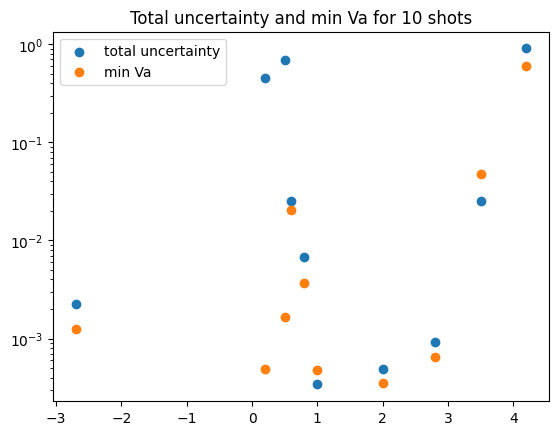

In [64]:
# plot x vs total uncertainty and min Va

plt.figure()
plt.scatter(shots_df['true_x'], shots_df['total_uncertainty'], label='total uncertainty')
plt.scatter(shots_df['true_x'], shots_df['min_Va'], label='min Va')
plt.title(f"Total uncertainty and min Va for {shots} shots")
plt.yscale('log')
plt.legend()
plt.show()

In [49]:
x_index = 5

In [50]:
# Data for specific x values


# Load results
shot_values = []
total_uncertainty_list = []
min_Va_list = []
max_Ve_list = []
true_x_list = []

for filename in os.listdir(results_directory):
    if f"x{x_index}" in filename:
        z_df = pd.read_csv(results_directory + filename)
        # Get the shot value from the filename "_{shot_value}_shot"
        shot_value = int(re.search(r'results_(\d+)_shot', filename).group(1))
        shot_values.append(shot_value)
        
        total_uncertainty = z_df["H[p(y|x)]"].values[0]
        total_uncertainty_list.append(total_uncertainty)
        
        min_Va = z_df["min_Va"].values[0]
        min_Va_list.append(min_Va)
        
        max_Ve = z_df["max_Ve"].values[0]
        max_Ve_list.append(max_Ve)
        
        true_x = z_df['true_x'].values[0]
        true_x_list.append(true_x)
        
# Create a dataframe from the lists
data = {'shot_values': shot_values,
        'total_uncertainty': total_uncertainty_list,
        'min_Va': min_Va_list,
        'max_Ve': max_Ve_list,
        'true_x': true_x_list}

x_df = pd.DataFrame(data)

x_df = x_df.sort_values(by='shot_values')

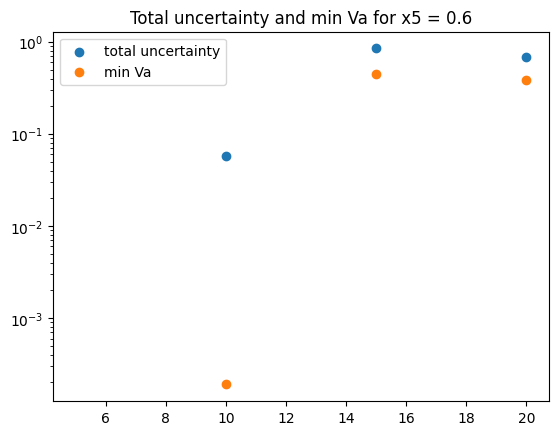

In [51]:
# plot shot values vs total uncertainty and min Va

plt.figure()
plt.scatter(x_df['shot_values'], x_df['total_uncertainty'], label='total uncertainty')
plt.scatter(x_df['shot_values'], x_df['min_Va'], label='min Va')
plt.title(f"Total uncertainty and min Va for x{x_index} = {x_df['true_x'].values[0]}")
plt.yscale("log")
plt.legend()
plt.show()